# Preprocessing Data
## Prediksi Hasil Panen Tanaman Berbasis Data Iklim dan Nutrisi Tanaman

| Informasi | Detail |
|-----------|--------|
| Dataset | `yield_df.csv` |
| Total baris (awal) | 28.242 |
| Total missing value | 0 |
| Total duplikat | 2.310 |

---

## 0. Import Library dan Load Dataset

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

os.makedirs('output', exist_ok=True)

df = pd.read_csv('dataset/yield_df.csv')
print('Shape awal:', df.shape)
df.head()

Shape awal: (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


---
## 3.1 Cek Missing Value

In [2]:
print('Jumlah Missing Value per Kolom')
print('==================================')

missing_count = df.isnull().sum()
missing_pct   = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase (%)': missing_pct.round(2)
})
print(missing_df)
print()
print('Total missing value:', missing_count.sum())

Jumlah Missing Value per Kolom
                               Jumlah Missing  Persentase (%)
Unnamed: 0                                  0             0.0
Area                                        0             0.0
Item                                        0             0.0
Year                                        0             0.0
hg/ha_yield                                 0             0.0
average_rain_fall_mm_per_year               0             0.0
pesticides_tonnes                           0             0.0
avg_temp                                    0             0.0

Total missing value: 0


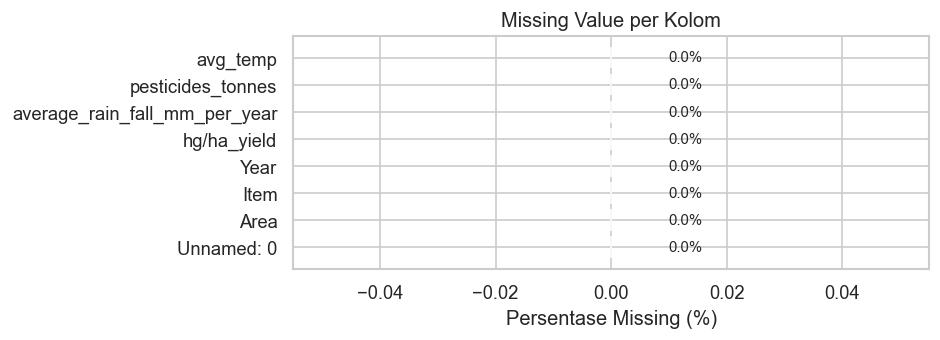

Hasil: Tidak ditemukan missing value pada seluruh kolom dataset.


In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
colors = ['#E74C3C' if v > 0 else '#2ECC71' for v in missing_pct.values]
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor='white')
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Missing Value per Kolom')
for bar, v in zip(bars, missing_pct.values):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('output/preprocessing_missing.png', bbox_inches='tight')
plt.show()
print('Hasil: Tidak ditemukan missing value pada seluruh kolom dataset.')

---
## 3.2 Deteksi dan Tangani Data Duplikat

In [4]:
n_before = len(df)
n_dup    = df.duplicated().sum()

print(f'Baris sebelum drop_duplicates : {n_before:,}')
print(f'Jumlah baris duplikat         : {n_dup:,} ({n_dup/n_before*100:.1f}%)')
print()
print('Contoh baris duplikat (5 baris pertama):')
display(df[df.duplicated()].head(5))

Baris sebelum drop_duplicates : 28,242
Jumlah baris duplikat         : 0 (0.0%)

Contoh baris duplikat (5 baris pertama):


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp


In [5]:
df.drop_duplicates(keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

n_after = len(df)
print(f'Baris sesudah drop_duplicates : {n_after:,}')
print(f'Baris yang dihapus            : {n_before - n_after:,}')

Baris sesudah drop_duplicates : 28,242
Baris yang dihapus            : 0


---
## 3.3 Deteksi dan Tangani Outlier (Metode IQR)

Strategi berdasarkan temuan EDA:

| Kolom | Strategi |
|-------|----------|
| `hg/ha_yield` | Dipertahankan (valid secara domain — variasi antar jenis tanaman) |
| `pesticides_tonnes` | Capping IQR (distribusi sangat right-skewed) |
| `average_rain_fall_mm_per_year` | Capping IQR (distribusi right-skewed) |
| `avg_temp` | Dipertahankan (valid secara geografis) |

In [6]:
num_cols = ['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count = ((df[num_cols] < lower) | (df[num_cols] > upper)).sum()

print('Jumlah Outlier per Kolom (Metode IQR)')
print('=======================================')
for col in num_cols:
    pct = outlier_count[col] / len(df) * 100
    print(f'  {col:<40}: {outlier_count[col]:>5} baris ({pct:.1f}%)')

Jumlah Outlier per Kolom (Metode IQR)
  hg/ha_yield                             :  2059 baris (7.3%)
  average_rain_fall_mm_per_year           :     0 baris (0.0%)
  pesticides_tonnes                       :  1418 baris (5.0%)
  avg_temp                                :    34 baris (0.1%)


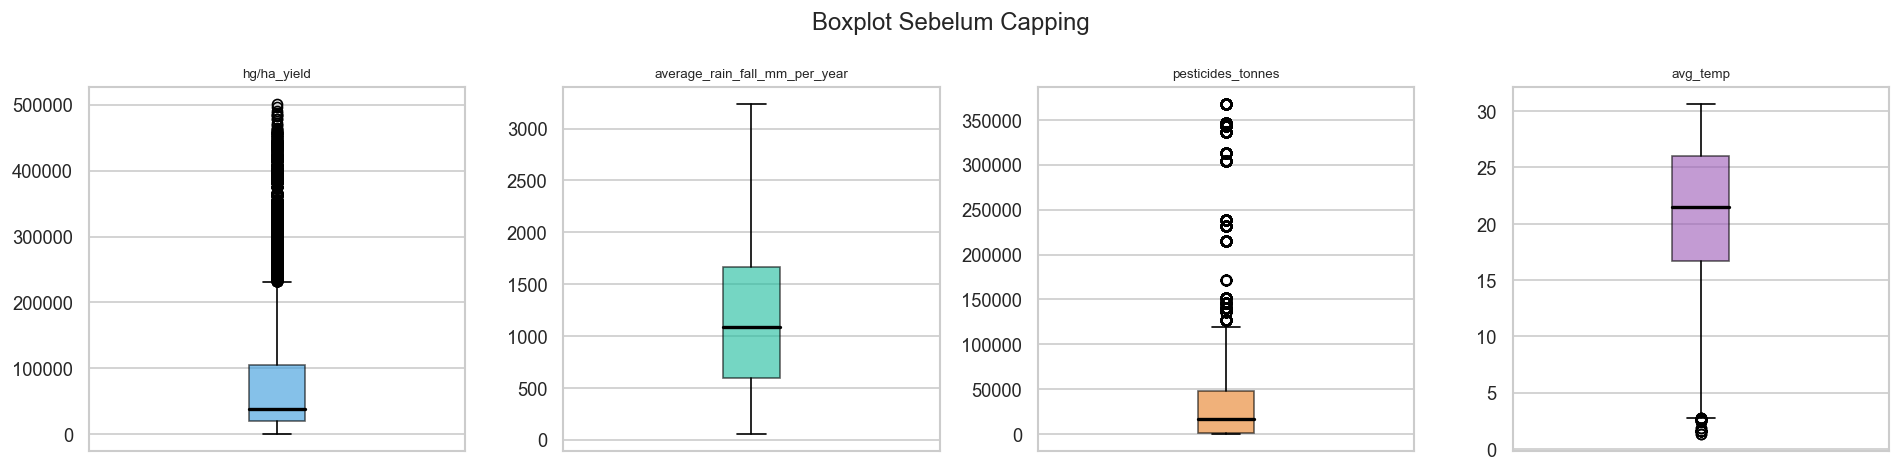

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#3498DB', '#1ABC9C', '#E67E22', '#9B59B6']
for ax, col, c in zip(axes, num_cols, colors):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=c, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontsize=8)
    ax.set_xticks([])
plt.suptitle('Boxplot Sebelum Capping')
plt.tight_layout()
plt.savefig('output/preprocessing_boxplot_before.png', bbox_inches='tight')
plt.show()

In [8]:
cap_cols = ['pesticides_tonnes', 'average_rain_fall_mm_per_year']

for col in cap_cols:
    before_min = df[col].min()
    before_max = df[col].max()
    df[col] = df[col].clip(lower=lower[col], upper=upper[col])
    after_min  = df[col].min()
    after_max  = df[col].max()
    print(f'{col}:')
    print(f'  Sebelum -> min: {before_min:.2f}, max: {before_max:.2f}')
    print(f'  Sesudah -> min: {after_min:.2f}, max: {after_max:.2f}')
    print()

print('Capping selesai.')
print('Kolom hg/ha_yield dan avg_temp tidak diubah (dipertahankan).')

pesticides_tonnes:
  Sebelum -> min: 0.04, max: 367778.00
  Sesudah -> min: 0.04, max: 119166.70

average_rain_fall_mm_per_year:
  Sebelum -> min: 51.00, max: 3240.00
  Sesudah -> min: 51.00, max: 3240.00

Capping selesai.
Kolom hg/ha_yield dan avg_temp tidak diubah (dipertahankan).


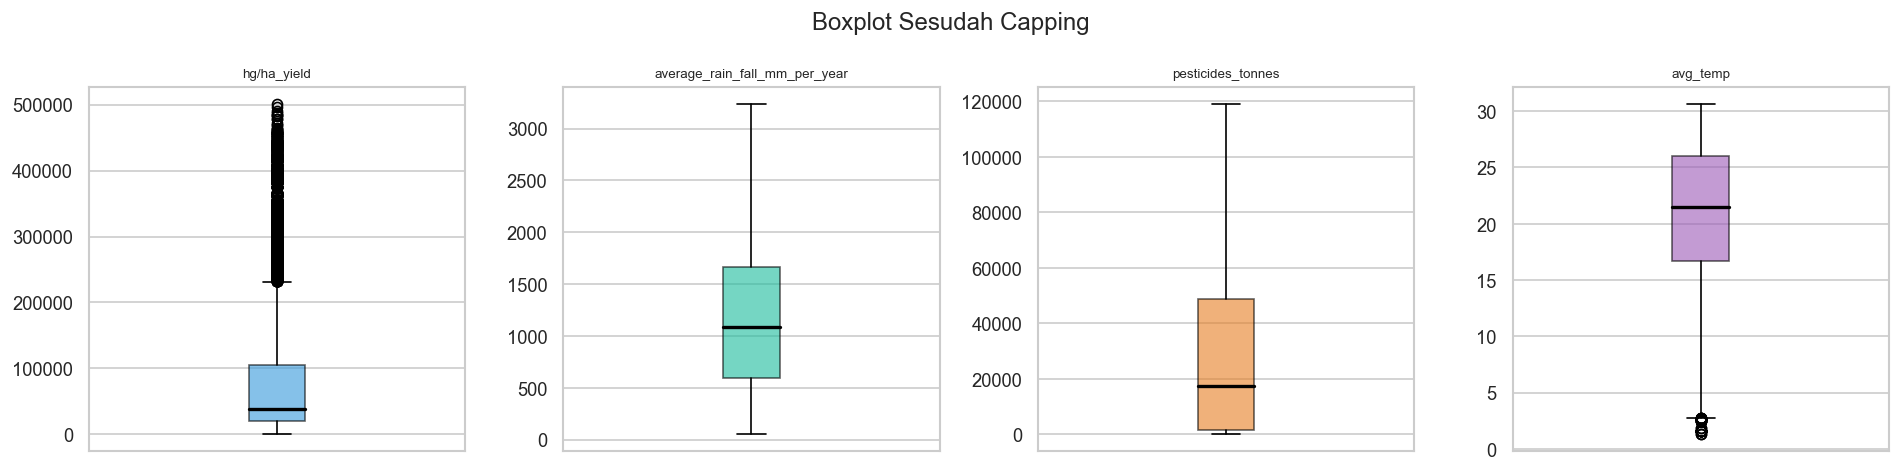

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col, c in zip(axes, num_cols, colors):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=c, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontsize=8)
    ax.set_xticks([])
plt.suptitle('Boxplot Sesudah Capping')
plt.tight_layout()
plt.savefig('output/preprocessing_boxplot_after.png', bbox_inches='tight')
plt.show()

---
## 3.4 Standarisasi Nama Kolom

In [10]:
print('Nama kolom sebelum standarisasi:')
print(df.columns.tolist())

df.rename(columns={'hg/ha_yield': 'yield_hg_ha'}, inplace=True)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print()
print('Nama kolom sesudah standarisasi:')
print(df.columns.tolist())

Nama kolom sebelum standarisasi:
['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

Nama kolom sesudah standarisasi:
['unnamed:_0', 'area', 'item', 'year', 'yield_hg_ha', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


---
## 3.5 Pisahkan Fitur Numerik dan Kategorikal

In [11]:
num_cols = ['year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
cat_cols = ['area', 'item']
target   = 'yield_hg_ha'

print('Fitur Numerik   :', num_cols)
print('Fitur Kategorikal:', cat_cols)
print('Target          :', target)
print()
print('Tipe data:')
print(df[num_cols + cat_cols + [target]].dtypes)

Fitur Numerik   : ['year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
Fitur Kategorikal: ['area', 'item']
Target          : yield_hg_ha

Tipe data:
year                               int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
area                              object
item                              object
yield_hg_ha                        int64
dtype: object


---
## 4.1 Encoding Variabel Kategorikal (Label Encoding)

Keputusan teknik:

| Teknik | Keputusan | Alasan |
|--------|-----------|--------|
| Label Encoding | Digunakan | Efisien; tidak menambah dimensi kolom |
| One-Hot Encoding | Tidak digunakan | Area dan Item memiliki banyak kategori unik — dimensionality explosion |
| Min-Max Scaler | Tidak digunakan | Random Forest berbasis threshold, tidak sensitif terhadap skala |
| SMOTE | Tidak relevan | Proyek ini adalah regresi, bukan klasifikasi |

In [12]:
le_area = LabelEncoder()
le_item = LabelEncoder()

df['area'] = le_area.fit_transform(df['area'])
df['item'] = le_item.fit_transform(df['item'])

print(f'Jumlah kelas Area : {len(le_area.classes_)}')
print(f'Jumlah kelas Item : {len(le_item.classes_)}')
print()
print('Contoh encoding Area (5 pertama):')
for i, label in enumerate(le_area.classes_[:5]):
    print(f'  {label} -> {i}')
print('  ...')
print()
df.head()

Jumlah kelas Area : 101
Jumlah kelas Item : 10

Contoh encoding Area (5 pertama):
  Albania -> 0
  Algeria -> 1
  Angola -> 2
  Argentina -> 3
  Armenia -> 4
  ...



,unnamed:_0,area,item,year,yield_hg_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,0,1,1990,36613,1485.0,121.0,16.37
1,1,0,3,1990,66667,1485.0,121.0,16.37
2,2,0,4,1990,23333,1485.0,121.0,16.37
3,3,0,5,1990,12500,1485.0,121.0,16.37
4,4,0,6,1990,7000,1485.0,121.0,16.37


---
## 4.4 Train-Test Split (80:20)

In [13]:
features = ['area', 'item', 'year', 'average_rain_fall_mm_per_year',
            'pesticides_tonnes', 'avg_temp']

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train-Test Split')
print('================')
print(f'Total data bersih : {len(df):,} baris')
print(f'X_train           : {X_train.shape}')
print(f'X_test            : {X_test.shape}')
print(f'y_train           : {y_train.shape}')
print(f'y_test            : {y_test.shape}')
print()
print(f'Proporsi Train : {len(X_train)/len(df)*100:.1f}%')
print(f'Proporsi Test  : {len(X_test)/len(df)*100:.1f}%')

Train-Test Split
Total data bersih : 28,242 baris
X_train           : (22593, 6)
X_test            : (5649, 6)
y_train           : (22593,)
y_test            : (5649,)

Proporsi Train : 80.0%
Proporsi Test  : 20.0%


---
## Ringkasan Preprocessing

In [14]:
print('=' * 55)
print('         RINGKASAN HASIL PREPROCESSING')
print('=' * 55)
print(f'  1. Missing value        : 0 (tidak ada)')
print(f'  2. Duplikat dihapus     : {n_before - n_after:,} baris')
print(f'     Sebelum              : {n_before:,} baris')
print(f'     Sesudah              : {n_after:,} baris')
print(f'  3. Outlier capping      : pesticides_tonnes,')
print(f'                           average_rain_fall_mm_per_year')
print(f'  4. Encoding             : Label Encoding (area, item)')
print(f'  5. Scaling              : Tidak digunakan (Random Forest)')
print(f'  6. SMOTE                : Tidak relevan (Regresi)')
print(f'  7. Train size           : {len(X_train):,} baris')
print(f'     Test  size           : {len(X_test):,} baris')
print('=' * 55)
print('  Data siap untuk tahap Modelling.')
print('=' * 55)

         RINGKASAN HASIL PREPROCESSING
  1. Missing value        : 0 (tidak ada)
  2. Duplikat dihapus     : 0 baris
     Sebelum              : 28,242 baris
     Sesudah              : 28,242 baris
  3. Outlier capping      : pesticides_tonnes,
                           average_rain_fall_mm_per_year
  4. Encoding             : Label Encoding (area, item)
  5. Scaling              : Tidak digunakan (Random Forest)
  6. SMOTE                : Tidak relevan (Regresi)
  7. Train size           : 22,593 baris
     Test  size           : 5,649 baris
  Data siap untuk tahap Modelling.


---
## Simpan Data Bersih

In [15]:
df.to_csv('output/yield_clean.csv', index=False)
X_train.to_csv('output/X_train.csv', index=False)
X_test.to_csv('output/X_test.csv', index=False)
y_train.to_csv('output/y_train.csv', index=False)
y_test.to_csv('output/y_test.csv', index=False)

print('File tersimpan di folder output/:')
print('  - yield_clean.csv')
print('  - X_train.csv / X_test.csv')
print('  - y_train.csv / y_test.csv')

File tersimpan di folder output/:
  - yield_clean.csv
  - X_train.csv / X_test.csv
  - y_train.csv / y_test.csv
